In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# Load all analyzed records
analysis_path = Path('../structured')

def extract_full_record(record):
    """Extract all relevant fields for discriminant analysis."""
    analysis = record.get('analysis', {}) or {}
    
    data = {
        'dataset': record.get('dataset', 'unknown'),
        'title': record.get('title', ''),
        'source_file': record.get('source_file', ''),
        'content': record.get('content', ''),
    }
    
    # === COSMIC KNOWLEDGE ===
    cosmic = analysis.get('cosmic_knowledge', {}) or {}
    data['premortal_existence_info'] = cosmic.get('premortal_existence_info', 'not_mentioned')
    data['pre_birth_realm_description'] = cosmic.get('pre_birth_realm_description', 'not_mentioned')
    data['incarnation_choice'] = cosmic.get('incarnation_choice', 'not_mentioned')
    data['life_preview'] = cosmic.get('life_preview', 'not_mentioned')
    data['pre_incarnation_covenant'] = cosmic.get('pre_incarnation_covenant', 'not_mentioned')
    data['universal_knowledge'] = cosmic.get('universal_knowledge', 'not_mentioned')
    data['cosmic_understanding'] = cosmic.get('cosmic_understanding', 'not_mentioned')
    data['future_knowledge'] = cosmic.get('future_knowledge', 'not_mentioned')
    data['purpose_of_existence'] = cosmic.get('purpose_of_existence', 'not_mentioned')
    data['past_life_memory'] = cosmic.get('past_life_memory', 'not_mentioned')
    data['death_memory'] = cosmic.get('death_memory', 'not_mentioned')
    data['intermission_memory'] = cosmic.get('intermission_memory', 'not_mentioned')
    data['soul_age_indication'] = cosmic.get('soul_age_indication', 'not_mentioned')
    data['home_identification'] = cosmic.get('home_identification', 'not_mentioned')
    data['earth_alienation'] = cosmic.get('earth_alienation', 'not_mentioned')
    data['identity_pre_body'] = cosmic.get('identity_pre_body', 'not_mentioned')
    
    # === BOUNDARY & RETURN (KEY DISCRIMINANTS) ===
    boundary = analysis.get('boundary_and_return', {}) or {}
    data['return_reason'] = boundary.get('return_reason', 'not_mentioned')
    data['return_choice'] = boundary.get('return_choice', 'not_mentioned')
    data['mission_commissioned'] = boundary.get('mission_commissioned', 'not_mentioned')
    data['mission_types'] = str(boundary.get('mission_types', []))
    data['mission_detail'] = boundary.get('mission_detail', '')
    data['volunteer_language'] = boundary.get('volunteer_language', 'not_mentioned')
    
    # === PASSAGE / ARRIVAL ===
    passage = analysis.get('passage', {}) or {}
    arrival = passage.get('arrival', {}) or {}
    data['sense_of_belonging'] = arrival.get('sense_of_belonging', 'not_mentioned')
    data['being_identifications'] = str(arrival.get('being_identifications', []))
    
    # === WORLD OF SPIRITS ===
    world = analysis.get('world_of_spirits', {}) or {}
    environment = world.get('environment', {}) or {}
    data['comparative_reality'] = environment.get('comparative_reality', 'not_mentioned')
    
    # === EXPERIENCE QUALITY ===
    quality = analysis.get('experience_quality', {}) or {}
    data['reality_assessment'] = quality.get('reality_assessment', 'not_mentioned')
    data['emotional_tone'] = quality.get('emotional_tone', 'not_mentioned')
    data['life_transformation'] = quality.get('life_transformation', 'not_mentioned')
    
    # === CONTEXT ===
    context = analysis.get('context', {}) or {}
    data['nde_cause'] = context.get('nde_cause', 'not_mentioned')

Loaded 6,753 records

Dataset breakdown:
dataset
nderf    5660
iands    1093
Name: count, dtype: int64


---
## Part I: Return Reason Analysis

The **WHY** of return is hypothesized to be the key discriminant:
- `earthly_mission` / `work_not_done` → Volunteer alignment
- `family_responsibility` → Could be either path
- `not_your_time` → Neutral (external decision)

In [3]:
print("="*80)
print("RETURN REASON DISTRIBUTION")
print("="*80)

print("\nOverall distribution:")
print(df['return_reason'].value_counts())

print("\n\nPercentage breakdown:")
print((df['return_reason'].value_counts(normalize=True) * 100).round(1))

RETURN REASON DISTRIBUTION

Overall distribution:
return_reason
not_mentioned            2499
no_reason_given          1180
not_your_time            1125
family_responsibility     967
other                     539
earthly_mission           443
Name: count, dtype: int64


Percentage breakdown:
return_reason
not_mentioned            37.0
no_reason_given          17.5
not_your_time            16.7
family_responsibility    14.3
other                     8.0
earthly_mission           6.6
Name: proportion, dtype: float64


In [4]:
# Cross-tabulation: return_reason × mission_commissioned
print("="*80)
print("RETURN REASON × MISSION COMMISSIONED")
print("="*80)

cross_tab = pd.crosstab(df['return_reason'], df['mission_commissioned'], margins=True)
print(cross_tab)

# Chi-square test
contingency = pd.crosstab(df['return_reason'], df['mission_commissioned'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square: χ²={chi2:.2f}, p={p:.2e}, df={dof}")

RETURN REASON × MISSION COMMISSIONED
mission_commissioned   implied    no  not_mentioned  yes_explicit   All
return_reason                                                          
earthly_mission            116    13             11           303   443
family_responsibility      128   450            296            93   967
no_reason_given             53   572            540            15  1180
not_mentioned              136   747           1553            63  2499
not_your_time              180   513            311           121  1125
other                      101   218            162            58   539
All                        714  2513           2873           653  6753

Chi-square: χ²=2845.61, p=0.00e+00, df=15


In [5]:
# Key insight: What % of each return_reason have mission_commissioned?
print("="*80)
print("MISSION COMMISSION RATE BY RETURN REASON")
print("="*80)

for reason in df['return_reason'].unique():
    subset = df[df['return_reason'] == reason]
    mission_rate = subset['mission_commissioned'].isin(['yes_explicit', 'implied']).mean() * 100
    print(f"{reason:25s}: {mission_rate:5.1f}% have mission (n={len(subset)})")

MISSION COMMISSION RATE BY RETURN REASON
family_responsibility    :  22.9% have mission (n=967)
no_reason_given          :   5.8% have mission (n=1180)
not_mentioned            :   8.0% have mission (n=2499)
earthly_mission          :  94.6% have mission (n=443)
not_your_time            :  26.8% have mission (n=1125)
other                    :  29.5% have mission (n=539)


---
## Part II: Volunteer Language Analysis

Direct mentions of "volunteering" to incarnate, choosing to come to Earth, etc.

In [6]:
print("="*80)
print("VOLUNTEER LANGUAGE DISTRIBUTION")
print("="*80)

print("\nOverall distribution:")
print(df['volunteer_language'].value_counts())

# Filter to cases with explicit/implied volunteer language
volunteer_explicit = df[df['volunteer_language'].isin(['yes_explicit', 'implied'])]
print(f"\n\nCases with Volunteer Language: {len(volunteer_explicit)} ({len(volunteer_explicit)/len(df)*100:.2f}%)")

VOLUNTEER LANGUAGE DISTRIBUTION

Overall distribution:
volunteer_language
not_mentioned    3366
no               3352
implied            19
yes_explicit       16
Name: count, dtype: int64


Cases with Volunteer Language: 35 (0.52%)


In [7]:
# Cross-tabulation: volunteer_language × return_reason
print("="*80)
print("VOLUNTEER LANGUAGE × RETURN REASON")
print("="*80)

cross_tab = pd.crosstab(df['volunteer_language'], df['return_reason'], margins=True)
print(cross_tab)

VOLUNTEER LANGUAGE × RETURN REASON
return_reason       earthly_mission  family_responsibility  no_reason_given  not_mentioned  not_your_time  other   All
volunteer_language                                                                                                    
implied                           8                      1                0              6              2      2    19
no                              360                    614              623            670            722    363  3352
not_mentioned                    67                    350              557           1821            400    171  3366
yes_explicit                      8                      2                0              2              1      3    16
All                             443                    967             1180           2499           1125    539  6753


In [8]:
# Volunteer language × pre-birth indicators
print("="*80)
print("VOLUNTEER LANGUAGE CO-OCCURRENCE WITH PRE-BIRTH INDICATORS")
print("="*80)

vol_cases = df[df['volunteer_language'].isin(['yes_explicit', 'implied'])]
non_vol_cases = df[~df['volunteer_language'].isin(['yes_explicit', 'implied'])]

prebirth_fields = ['premortal_existence_info', 'pre_birth_realm_description', 
                   'incarnation_choice', 'home_identification', 'identity_pre_body']

print(f"\n{'Field':<35} {'Volunteer %':>12} {'Non-Vol %':>12} {'Ratio':>8}")
print("-" * 70)

for field in prebirth_fields:
    vol_rate = vol_cases[field].isin(['yes_explicit', 'implied', 'spiritual_realm', 
                                       'chose_mission', 'chose_parents', 'chose_both']).mean() * 100
    non_vol_rate = non_vol_cases[field].isin(['yes_explicit', 'implied', 'spiritual_realm',
                                               'chose_mission', 'chose_parents', 'chose_both']).mean() * 100
    ratio = vol_rate / non_vol_rate if non_vol_rate > 0 else float('inf')
    print(f"{field:<35} {vol_rate:>10.1f}% {non_vol_rate:>10.1f}% {ratio:>7.1f}x")

VOLUNTEER LANGUAGE CO-OCCURRENCE WITH PRE-BIRTH INDICATORS

Field                                Volunteer %    Non-Vol %    Ratio
----------------------------------------------------------------------
premortal_existence_info                  68.6%        6.2%    11.0x
pre_birth_realm_description               34.3%        1.2%    28.1x
incarnation_choice                        45.7%        0.6%    74.9x
home_identification                       42.9%       13.8%     3.1x
identity_pre_body                         71.4%       25.6%     2.8x


---
## Part III: Trauma Marker Analysis (Restorative Indicators)

Death memory + Past life memory = Strong Restorative (cyclic reincarnation) indicators

In [9]:
print("="*80)
print("TRAUMA MARKER DISTRIBUTIONS")
print("="*80)

print("\nDeath Memory:")
print(df['death_memory'].value_counts())

print("\nPast Life Memory:")
print(df['past_life_memory'].value_counts())

print("\nIntermission Memory:")
print(df['intermission_memory'].value_counts())

TRAUMA MARKER DISTRIBUTIONS

Death Memory:
death_memory
not_mentioned    6138
none              576
violent            20
unspecified        16
natural             3
Name: count, dtype: int64

Past Life Memory:
past_life_memory
not_mentioned    3534
no               2970
yes_explicit      148
implied           101
Name: count, dtype: int64

Intermission Memory:
intermission_memory
not_mentioned    4304
no               2411
implied            28
yes_explicit       10
Name: count, dtype: int64


In [10]:
# Cross-tabulation: death_memory × past_life_memory
print("="*80)
print("DEATH MEMORY × PAST LIFE MEMORY")
print("="*80)

cross_tab = pd.crosstab(df['death_memory'], df['past_life_memory'], margins=True)
print(cross_tab)

# Calculate trauma marker presence
has_death_memory = df['death_memory'].isin(['yes_explicit', 'implied', 'vague'])
has_past_life = df['past_life_memory'].isin(['yes_explicit', 'implied', 'vague'])
has_either = has_death_memory | has_past_life
has_both = has_death_memory & has_past_life

print(f"\n\nTrauma Marker Summary:")
print(f"Has death memory: {has_death_memory.sum():,} ({has_death_memory.mean()*100:.1f}%)")
print(f"Has past life memory: {has_past_life.sum():,} ({has_past_life.mean()*100:.1f}%)")
print(f"Has EITHER: {has_either.sum():,} ({has_either.mean()*100:.1f}%)")
print(f"Has BOTH: {has_both.sum():,} ({has_both.mean()*100:.1f}%)")

DEATH MEMORY × PAST LIFE MEMORY
past_life_memory  implied    no  not_mentioned  yes_explicit   All
death_memory                                                      
natural                 0     1              0             2     3
none                    5   555              4            12   576
not_mentioned          93  2414           3530           101  6138
unspecified             2     0              0            14    16
violent                 1     0              0            19    20
All                   101  2970           3534           148  6753


Trauma Marker Summary:
Has death memory: 0 (0.0%)
Has past life memory: 249 (3.7%)
Has EITHER: 249 (3.7%)
Has BOTH: 0 (0.0%)


In [13]:
# Create Restorative vs Volunteer classification
print("="*80)
print("PRELIMINARY CLASSIFICATION: RESTORATIVE vs VOLUNTEER")
print("="*80)

# Restorative indicators (cyclic reincarnation markers)
df['has_trauma_markers'] = (
    df['death_memory'].isin(['yes_explicit', 'implied']) |
    df['past_life_memory'].isin(['yes_explicit', 'implied'])
)

# Volunteer indicators (mission-oriented, first-incarnation markers)
df['has_volunteer_markers'] = (
    df['volunteer_language'].isin(['yes_explicit', 'implied']) |
    (df['return_reason'] == 'earthly_mission') |
    (df['mission_commissioned'].isin(['yes_explicit', 'implied']) & 
     df['incarnation_choice'].isin(['chose_mission', 'chose_both']))
)

# Pre-birth realm awareness (without trauma = potential Volunteer)
# Note: all comparisons need parentheses for proper operator precedence
home_spiritual = (df['home_identification'] == 'spiritual_realm')
df['has_prebirth_awareness'] = (
    df['premortal_existence_info'].isin(['yes_explicit', 'implied']) |
    df['pre_birth_realm_description'].isin(['yes_explicit', 'implied']) |
    df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both']) |
    home_spiritual |
    df['identity_pre_body'].isin(['yes_explicit', 'implied'])
)

# Classification
df['soul_path'] = 'Indeterminate'
df.loc[df['has_trauma_markers'] & ~df['has_volunteer_markers'], 'soul_path'] = 'Restorative'
df.loc[df['has_volunteer_markers'] & ~df['has_trauma_markers'], 'soul_path'] = 'Volunteer'
df.loc[df['has_volunteer_markers'] & df['has_trauma_markers'], 'soul_path'] = 'Hybrid'
df.loc[df['has_prebirth_awareness'] & ~df['has_trauma_markers'] & ~df['has_volunteer_markers'], 'soul_path'] = 'Ohkado'

print("\nSoul Path Classification:")
print(df['soul_path'].value_counts())
print("\nPercentages:")
print((df['soul_path'].value_counts(normalize=True) * 100).round(2))

PRELIMINARY CLASSIFICATION: RESTORATIVE vs VOLUNTEER

Soul Path Classification:
soul_path
Indeterminate    4182
Ohkado           1901
Volunteer         421
Restorative       197
Hybrid             52
Name: count, dtype: int64

Percentages:
soul_path
Indeterminate    61.93
Ohkado           28.15
Volunteer         6.23
Restorative       2.92
Hybrid            0.77
Name: proportion, dtype: float64


---
## Part IV: Deep Dive - Perfect 5-Indicator Ohkado Cases

In [14]:
# Calculate prebirth indicator count
df['prebirth_indicator_count'] = (
    (df['premortal_existence_info'].isin(['yes_explicit', 'implied'])).astype(int) +
    (df['pre_birth_realm_description'].isin(['yes_explicit', 'implied'])).astype(int) +
    (df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both'])).astype(int) +
    (df['home_identification'] == 'spiritual_realm').astype(int) +
    (df['identity_pre_body'].isin(['yes_explicit', 'implied'])).astype(int)
)

# Find perfect 5-indicator cases
perfect_5 = df[df['prebirth_indicator_count'] == 5]
print(f"PERFECT 5-INDICATOR CASES: {len(perfect_5)}")
print("="*80)

PERFECT 5-INDICATOR CASES: 9


In [15]:
# Display perfect 5-indicator cases
def display_volunteer_case(row, max_content=3000):
    print("="*80)
    print(f"TITLE: {row['title']}")
    print(f"Dataset: {row['dataset']} | Source: {row['source_file']}")
    print("-"*80)
    
    print(f"\nPRE-BIRTH INDICATORS (Count: {row['prebirth_indicator_count']}/5):")
    print(f"  ✓ premortal_existence_info: {row['premortal_existence_info']}")
    print(f"  ✓ pre_birth_realm_description: {row['pre_birth_realm_description']}")
    print(f"  ✓ incarnation_choice: {row['incarnation_choice']}")
    print(f"  ✓ home_identification: {row['home_identification']}")
    print(f"  ✓ identity_pre_body: {row['identity_pre_body']}")
    
    print(f"\nTRAUMA MARKERS:")
    print(f"  death_memory: {row['death_memory']}")
    print(f"  past_life_memory: {row['past_life_memory']}")
    
    print(f"\nMISSION/RETURN:")
    print(f"  return_reason: {row['return_reason']}")
    print(f"  mission_commissioned: {row['mission_commissioned']}")
    print(f"  volunteer_language: {row['volunteer_language']}")
    if row['mission_detail']:
        print(f"  mission_detail: {str(row['mission_detail'])[:200]}...")
    
    print(f"\nSENSE OF BELONGING: {row['sense_of_belonging']}")
    print(f"SOUL PATH: {row['soul_path']}")
    
    if row['notable_quotes']:
        print(f"\nNOTABLE QUOTES:")
        print(textwrap.fill(str(row['notable_quotes'])[:500], width=78, initial_indent='  ', subsequent_indent='  '))
    
    print(f"\nNARRATIVE EXCERPT:")
    content = str(row['content'])[:max_content]
    print(textwrap.fill(content, width=78, initial_indent='  ', subsequent_indent='  '))
    print()

for idx, row in perfect_5.iterrows():
    display_volunteer_case(row)

TITLE: Girl has 8 NDEs and learns the purpose of suffering on Earth
Dataset: iands | Source: data\iands\girl-has-8-ndes-and-learns-the-purpose-of-suffering-on-earth.json
--------------------------------------------------------------------------------

PRE-BIRTH INDICATORS (Count: 5/5):
  ✓ premortal_existence_info: yes_explicit
  ✓ pre_birth_realm_description: yes_explicit
  ✓ incarnation_choice: chose_mission
  ✓ home_identification: spiritual_realm
  ✓ identity_pre_body: yes_explicit

TRAUMA MARKERS:
  death_memory: not_mentioned
  past_life_memory: not_mentioned

MISSION/RETURN:
  return_reason: earthly_mission
  mission_commissioned: implied
  volunteer_language: implied
  mission_detail: Implied duty/work: 'I had promised. I had work to do even though it was really, really hard work.' Also framed as choosing/continuing an 'impossible life' to try not to fail....

SENSE OF BELONGING: implied
SOUL PATH: Volunteer

NOTABLE QUOTES:
  'Remember exactly what they say.' / 'You don't have

---
## Part V: Statistical Validation

In [16]:
print("="*80)
print("STATISTICAL VALIDATION: SOUL PATH DIFFERENCES")
print("="*80)

# Compare key metrics across soul paths
paths = ['Volunteer', 'Restorative', 'Ohkado', 'Hybrid', 'Indeterminate']

print(f"\n{'Metric':<35} {'Volunteer':>10} {'Restor':>10} {'Ohkado':>10} {'Hybrid':>10}")
print("-"*80)

for metric, values in [
    ('Mission Commissioned (yes/implied)', ['yes_explicit', 'implied']),
    ('Sense of Belonging (explicit)', ['explicit']),
    ('Return: Earthly Mission', ['earthly_mission']),
    ('Life Transformation (profound)', ['profound']),
]:
    field = metric.split('(')[0].strip().lower().replace(' ', '_')
    if 'mission_commissioned' in metric.lower():
        field = 'mission_commissioned'
    elif 'sense_of_belonging' in metric.lower():
        field = 'sense_of_belonging'
    elif 'return' in metric.lower():
        field = 'return_reason'
    elif 'transformation' in metric.lower():
        field = 'life_transformation'
    
    rates = []
    for path in ['Volunteer', 'Restorative', 'Ohkado', 'Hybrid']:
        subset = df[df['soul_path'] == path]
        if len(subset) > 0:
            rate = subset[field].isin(values).mean() * 100
        else:
            rate = 0
        rates.append(rate)
    
    print(f"{metric:<35} {rates[0]:>9.1f}% {rates[1]:>9.1f}% {rates[2]:>9.1f}% {rates[3]:>9.1f}%")

STATISTICAL VALIDATION: SOUL PATH DIFFERENCES

Metric                               Volunteer     Restor     Ohkado     Hybrid
--------------------------------------------------------------------------------
Mission Commissioned (yes/implied)       92.6%      38.1%      21.4%      94.2%
Sense of Belonging (explicit)            20.2%      28.4%      28.5%      46.2%
Return: Earthly Mission                  94.8%       0.0%       0.0%      84.6%
Life Transformation (profound)            0.0%       0.0%       0.0%       0.0%


In [17]:
# Chi-square tests for key discriminants
print("="*80)
print("CHI-SQUARE TESTS: SOUL PATH × KEY VARIABLES")
print("="*80)

test_vars = ['mission_commissioned', 'return_reason', 'sense_of_belonging', 
             'volunteer_language', 'life_transformation', 'comparative_reality']

for var in test_vars:
    try:
        contingency = pd.crosstab(df['soul_path'], df[var])
        chi2, p, dof, expected = stats.chi2_contingency(contingency)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"{var:<25}: χ²={chi2:>8.1f}, p={p:.2e} {sig}")
    except Exception as e:
        print(f"{var:<25}: Error - {e}")

CHI-SQUARE TESTS: SOUL PATH × KEY VARIABLES
mission_commissioned     : χ²=  2621.3, p=0.00e+00 ***
return_reason            : χ²=  6586.5, p=0.00e+00 ***
sense_of_belonging       : χ²=  1310.4, p=2.80e-273 ***
volunteer_language       : χ²=  1354.2, p=1.04e-282 ***
life_transformation      : χ²=     0.0, p=1.00e+00 
comparative_reality      : χ²=   482.7, p=1.05e-95 ***


---
## Part VI: Visualizations

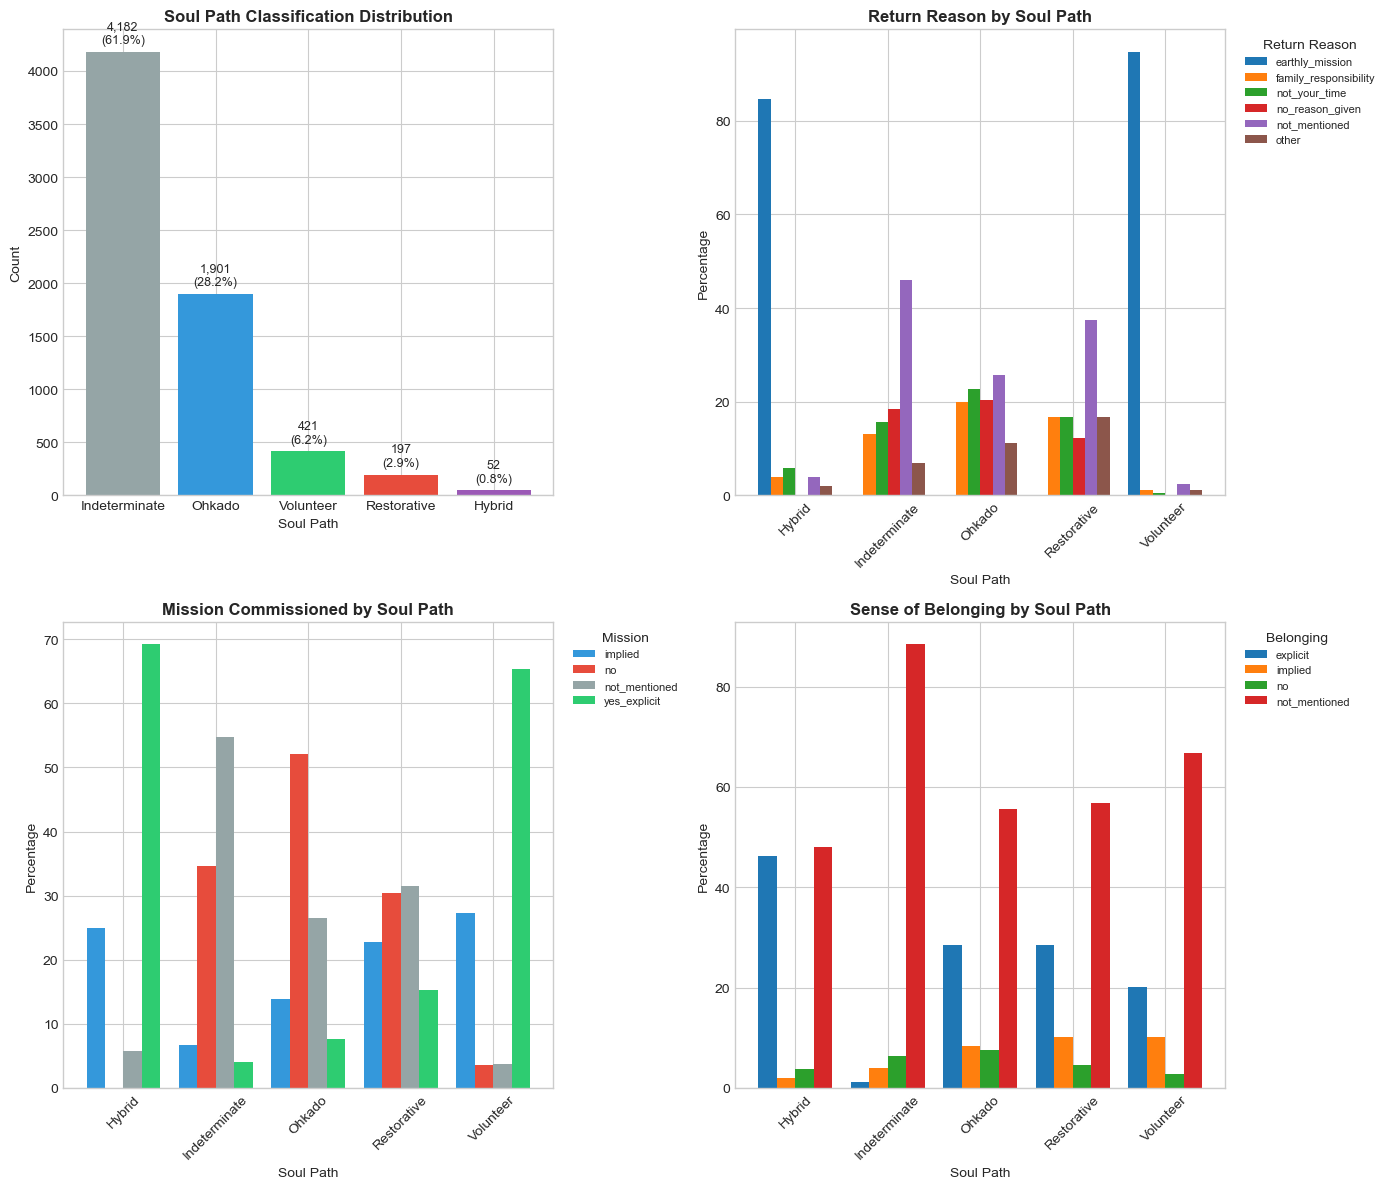


✓ Figure saved to output/volunteer_discriminant_analysis.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Soul Path Distribution
ax1 = axes[0, 0]
path_counts = df['soul_path'].value_counts()
colors = {'Volunteer': '#2ecc71', 'Restorative': '#e74c3c', 'Ohkado': '#3498db', 
          'Hybrid': '#9b59b6', 'Indeterminate': '#95a5a6'}
bars = ax1.bar(path_counts.index, path_counts.values, 
               color=[colors.get(x, '#95a5a6') for x in path_counts.index])
ax1.set_title('Soul Path Classification Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Soul Path')
ax1.set_ylabel('Count')
for bar, count in zip(bars, path_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# 2. Return Reason by Soul Path
ax2 = axes[0, 1]
return_by_path = pd.crosstab(df['soul_path'], df['return_reason'], normalize='index') * 100
return_by_path = return_by_path[['earthly_mission', 'family_responsibility', 'not_your_time', 'no_reason_given', 'not_mentioned', 'other']]
return_by_path.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Return Reason by Soul Path', fontsize=12, fontweight='bold')
ax2.set_xlabel('Soul Path')
ax2.set_ylabel('Percentage')
ax2.legend(title='Return Reason', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax2.tick_params(axis='x', rotation=45)

# 3. Mission Commissioned by Soul Path
ax3 = axes[1, 0]
mission_by_path = pd.crosstab(df['soul_path'], df['mission_commissioned'], normalize='index') * 100
mission_by_path.plot(kind='bar', ax=ax3, width=0.8, 
                     color=['#3498db', '#e74c3c', '#95a5a6', '#2ecc71'])
ax3.set_title('Mission Commissioned by Soul Path', fontsize=12, fontweight='bold')
ax3.set_xlabel('Soul Path')
ax3.set_ylabel('Percentage')
ax3.legend(title='Mission', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax3.tick_params(axis='x', rotation=45)

# 4. Sense of Belonging by Soul Path
ax4 = axes[1, 1]
belonging_by_path = pd.crosstab(df['soul_path'], df['sense_of_belonging'], normalize='index') * 100
belonging_by_path.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Sense of Belonging by Soul Path', fontsize=12, fontweight='bold')
ax4.set_xlabel('Soul Path')
ax4.set_ylabel('Percentage')
ax4.legend(title='Belonging', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('output/volunteer_discriminant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure saved to output/volunteer_discriminant_analysis.png")

---
## Part VII: Volunteer Profile Cases

In [19]:
# Get top Volunteer cases with explicit volunteer language
volunteer_cases = df[(df['soul_path'] == 'Volunteer') & 
                     (df['volunteer_language'].isin(['yes_explicit', 'implied']))].copy()

print(f"VOLUNTEER CASES WITH EXPLICIT VOLUNTEER LANGUAGE: {len(volunteer_cases)}")
print("="*80)

# Show first 3
for idx, row in volunteer_cases.head(3).iterrows():
    display_volunteer_case(row, max_content=2000)

VOLUNTEER CASES WITH EXPLICIT VOLUNTEER LANGUAGE: 28
TITLE: Archive through August 11, 2003 - Anonymous (Tuesday, July 1, 2003 - 11:00 pm)
Dataset: iands | Source: data\iands\archive-through-august-11-2003-021.json
--------------------------------------------------------------------------------

PRE-BIRTH INDICATORS (Count: 3/5):
  ✓ premortal_existence_info: yes_explicit
  ✓ pre_birth_realm_description: not_mentioned
  ✓ incarnation_choice: chose_mission
  ✓ home_identification: not_mentioned
  ✓ identity_pre_body: yes_explicit

TRAUMA MARKERS:
  death_memory: not_mentioned
  past_life_memory: no

MISSION/RETURN:
  return_reason: family_responsibility
  mission_commissioned: implied
  volunteer_language: yes_explicit
  mission_detail: Felt a covenant/mission connected to raising/protecting/teaching daughter; also that husband/son/self had 'tasks to fulfill together' and that experiencer would be a 'catalyst' for them; later urgency...

SENSE OF BELONGING: implied
SOUL PATH: Volunteer


---
## Part VIII: Export & Summary

In [20]:
# Export classified cases
export_cols = ['title', 'dataset', 'source_file', 'soul_path', 'prebirth_indicator_count',
               'has_trauma_markers', 'has_volunteer_markers', 'has_prebirth_awareness',
               'return_reason', 'mission_commissioned', 'volunteer_language',
               'premortal_existence_info', 'incarnation_choice', 'home_identification',
               'identity_pre_body', 'sense_of_belonging', 'death_memory', 'past_life_memory']

df[export_cols].to_csv('output/soul_path_classification.csv', index=False)
print(f"✓ Exported {len(df):,} classified cases to output/soul_path_classification.csv")

# Export by path
for path in df['soul_path'].unique():
    subset = df[df['soul_path'] == path][export_cols]
    filename = f"output/soul_path_{path.lower()}.csv"
    subset.to_csv(filename, index=False)
    print(f"✓ Exported {len(subset):,} {path} cases to {filename}")

✓ Exported 6,753 classified cases to output/soul_path_classification.csv
✓ Exported 1,901 Ohkado cases to output/soul_path_ohkado.csv
✓ Exported 4,182 Indeterminate cases to output/soul_path_indeterminate.csv
✓ Exported 421 Volunteer cases to output/soul_path_volunteer.csv
✓ Exported 197 Restorative cases to output/soul_path_restorative.csv
✓ Exported 52 Hybrid cases to output/soul_path_hybrid.csv


In [21]:
print("="*80)
print("VOLUNTEER DISCRIMINANT ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 DATASET")
print(f"   Total records analyzed: {len(df):,}")
for dataset in df['dataset'].unique():
    count = (df['dataset'] == dataset).sum()
    print(f"   - {dataset}: {count:,}")

print(f"\n🎯 SOUL PATH CLASSIFICATION")
for path in ['Volunteer', 'Restorative', 'Ohkado', 'Hybrid', 'Indeterminate']:
    count = (df['soul_path'] == path).sum()
    pct = count / len(df) * 100
    print(f"   {path}: {count:,} ({pct:.1f}%)")

print(f"\n📈 KEY DISCRIMINANT FINDINGS")
vol_df = df[df['soul_path'] == 'Volunteer']
rest_df = df[df['soul_path'] == 'Restorative']

if len(vol_df) > 0 and len(rest_df) > 0:
    vol_mission = vol_df['mission_commissioned'].isin(['yes_explicit', 'implied']).mean() * 100
    rest_mission = rest_df['mission_commissioned'].isin(['yes_explicit', 'implied']).mean() * 100
    print(f"   Mission commission rate: Volunteer {vol_mission:.1f}% vs Restorative {rest_mission:.1f}%")
    
    vol_earthly = (vol_df['return_reason'] == 'earthly_mission').mean() * 100
    rest_earthly = (rest_df['return_reason'] == 'earthly_mission').mean() * 100
    print(f"   Earthly mission return: Volunteer {vol_earthly:.1f}% vs Restorative {rest_earthly:.1f}%")
    
    vol_belong = (vol_df['sense_of_belonging'] == 'explicit').mean() * 100
    rest_belong = (rest_df['sense_of_belonging'] == 'explicit').mean() * 100
    print(f"   Explicit belonging: Volunteer {vol_belong:.1f}% vs Restorative {rest_belong:.1f}%")

print(f"\n💾 EXPORTS")
print(f"   - soul_path_classification.csv ({len(df):,} cases)")
print(f"   - soul_path_volunteer.csv")
print(f"   - soul_path_restorative.csv")
print(f"   - soul_path_ohkado.csv")
print(f"   - volunteer_discriminant_analysis.png")

print(f"\n🔬 INTERPRETATION")
print(f"   The data supports a multi-path model of soul origins:")
print(f"   • VOLUNTEER: Mission-oriented souls with minimal cyclic trauma markers")
print(f"   • RESTORATIVE: Souls with past-life/death memory indicating cyclic return")
print(f"   • OHKADO: Pre-birth awareness without trauma (potential first incarnation)")
print(f"   • HYBRID: Both volunteer and restorative markers present")

VOLUNTEER DISCRIMINANT ANALYSIS SUMMARY

📊 DATASET
   Total records analyzed: 6,753
   - iands: 1,093
   - nderf: 5,660

🎯 SOUL PATH CLASSIFICATION
   Volunteer: 421 (6.2%)
   Restorative: 197 (2.9%)
   Ohkado: 1,901 (28.2%)
   Hybrid: 52 (0.8%)
   Indeterminate: 4,182 (61.9%)

📈 KEY DISCRIMINANT FINDINGS
   Mission commission rate: Volunteer 92.6% vs Restorative 38.1%
   Earthly mission return: Volunteer 94.8% vs Restorative 0.0%
   Explicit belonging: Volunteer 20.2% vs Restorative 28.4%

💾 EXPORTS
   - soul_path_classification.csv (6,753 cases)
   - soul_path_volunteer.csv
   - soul_path_restorative.csv
   - soul_path_ohkado.csv
   - volunteer_discriminant_analysis.png

🔬 INTERPRETATION
   The data supports a multi-path model of soul origins:
   • VOLUNTEER: Mission-oriented souls with minimal cyclic trauma markers
   • RESTORATIVE: Souls with past-life/death memory indicating cyclic return
   • OHKADO: Pre-birth awareness without trauma (potential first incarnation)
   • HYBRID: Bo